In [2]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

c:\Users\yhk25\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = df[df['job_title_short'] == 'Data Analyst']

In [4]:
df_exploded = df.explode('job_skills')

df_exploded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,python,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,sql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,nosql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,power bi,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785717,Data Analyst,Data & Analytics Architect (w/m/x),"Erfurt, Jerman",melalui LinkedIn,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,NTT DATA DACH,azure,"{'cloud': ['aws', 'azure']}"
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,sas,"{'analyst_tools': ['sas', 'excel'], 'programmi..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,sas,"{'analyst_tools': ['sas', 'excel'], 'programmi..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,sql,"{'analyst_tools': ['sas', 'excel'], 'programmi..."


In [5]:
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_salary = ('salary_year_avg', 'median')
)

skill_stats = skill_stats.sort_values(by = 'skill_count', ascending = False).head(10)
skill_stats

,skill_count,median_salary
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


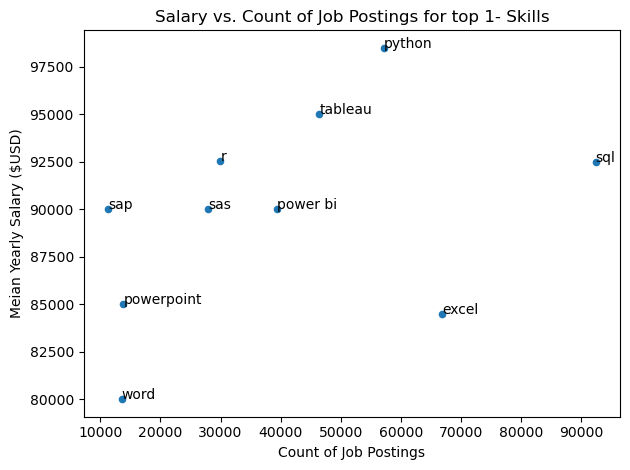

In [15]:
skill_stats.plot(kind = 'scatter', x = 'skill_count', y = 'median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Meian Yearly Salary ($USD)')
plt.title('Salary vs. Count of Job Postings for top 1- Skills')
plt.tight_layout()

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt)

plt.show()

## Again

In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [2]:
df = df[df['job_title_short'] == 'Data Analyst'].copy()

In [3]:
df_exploded = df.explode('job_skills')

In [4]:
skill_stats = df_exploded.groupby('job_skills').agg(
    median_salary = ('salary_year_avg', 'median'),
    skill_count = ('job_skills', 'count')
)

skill_stats

,median_salary,skill_count
job_skills,,
airflow,111175.0,2002
airtable,90000.0,88
alteryx,105000.0,4570
angular,109101.0,376
angular.js,NaN,2
...,...,...
wrike,75000.0,39
wsl,NaN,16
xamarin,NaN,2


In [5]:
skill_stats = skill_stats.sort_values(by = 'skill_count', ascending = False).head(10)

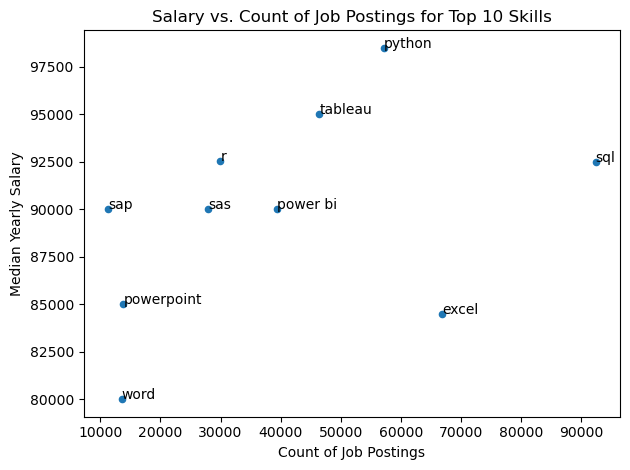

In [9]:
skill_stats.plot(kind = 'scatter', x = 'skill_count', y = 'median_salary')

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title('Salary vs. Count of Job Postings for Top 10 Skills')

for i, txt in enumerate(skill_stats.index):
    plt.text(
        skill_stats['skill_count'].iloc[i],
        skill_stats['median_salary'].iloc[i],
        txt
    )

plt.tight_layout()
plt.show()

## Problem

In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

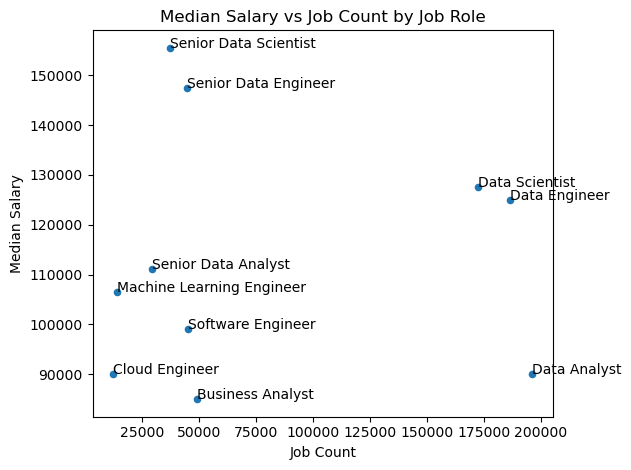

In [2]:
job_stats = df.groupby('job_title_short').agg(
    job_count = ('job_title_short', 'count'),
    median_salary = ('salary_year_avg', 'median')
)

job_stats.plot(
    kind = 'scatter',
    x = 'job_count',
    y = 'median_salary'
)

for i, txt in enumerate(job_stats.index):
    plt.text(
        job_stats['job_count'].iloc[i],
        job_stats['median_salary'].iloc[i],
        txt
    )

plt.xlabel('Job Count')
plt.ylabel('Median Salary')
plt.title('Median Salary vs Job Count by Job Role')
plt.tight_layout()
plt.show()

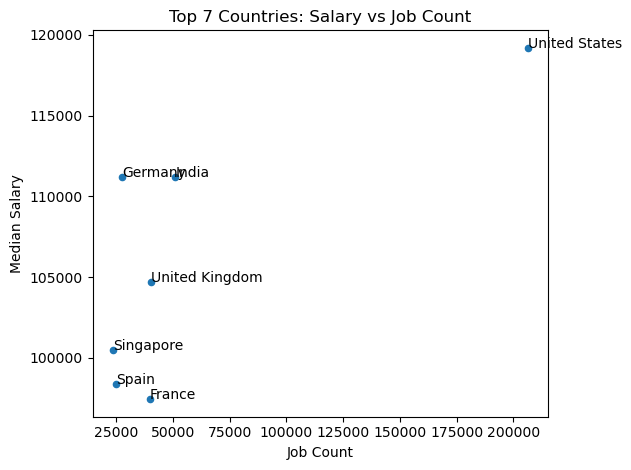

In [3]:
country_stats = df.groupby('job_country').agg(
    job_count=('job_country', 'count'),
    median_salary=('salary_year_avg', 'median')
)

country_stats = country_stats.sort_values(
    by = 'job_count', 
    ascending = False,
).head(7)

country_stats.plot(
    kind = 'scatter',
    x = 'job_count',
    y = 'median_salary'
)

for i, txt in enumerate(country_stats.index):
    plt.text(
        country_stats['job_count'].iloc[i],
        country_stats['median_salary'].iloc[i],
        txt
    )

plt.xlabel('Job Count')
plt.ylabel('Median Salary')
plt.title('Top 7 Countries: Salary vs Job Count')
plt.tight_layout()
plt.show()

In [5]:
target_job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

df_filtered = df[df['job_title_short'].isin(target_job_titles)]

schedule_stats = df_filtered.groupby(
    ['job_title_short', 'job_schedule_type']
).agg(
    job_count=('job_title_short', 'count'),
    avg_salary=('salary_year_avg', 'mean')
).reset_index()

schedule_stats

,job_title_short,job_schedule_type,job_count,avg_salary
0,Data Analyst,Contractor,10009,85289.169502
1,Data Analyst,Contractor and Full-time,1,NaN
2,Data Analyst,Contractor and Internship,8,NaN
3,Data Analyst,Contractor and Per diem,2,NaN
4,Data Analyst,Contractor and Temp work,549,78750.000000
...,...,...,...,...
103,Data Scientist,Pekerjaan tetap,3,NaN
104,Data Scientist,Per diem,3,NaN
105,Data Scientist,Temp work,439,83333.333333
106,Data Scientist,Temp work and Internship,82,NaN


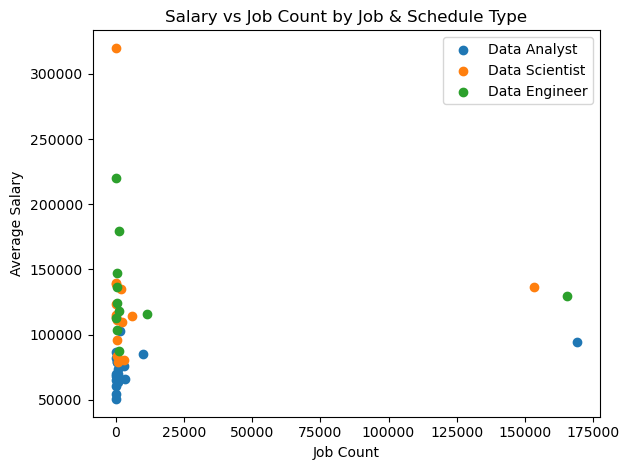

In [6]:
for job in target_job_titles:
    subset = schedule_stats[schedule_stats['job_title_short'] == job]

    plt.scatter(
        subset['job_count'],
        subset['avg_salary'],
        label = job
    )

plt.legend()
plt.xlabel('Job Count')
plt.ylabel('Average Salary')
plt.title('Salary vs Job Count by Job & Schedule Type')
plt.tight_layout()
plt.show()